# Outlier Neuron Filtering (Run First)
This notebook removes 6 outlier neurons based on Day 1 vs Day 2 mismatch in orientation-averaged activity.
All downstream dataset loads use this global keep-neuron mask automatically.
Removed IDs are stored in `OUTLIER_NEURON_IDS` and retained IDs in `KEEP_NEURON_IDS`.

Loaded day 1 file: /Users/bhaishahster/Data/xie_lab/icms_150_june_26_2day_unit_registered_data/visual_day1_registered.npz
Loaded day 2 file: /Users/bhaishahster/Data/xie_lab/icms_150_june_26_2day_unit_registered_data/visual_day2_registered.npz
Highlighted removed neuron IDs: [ 3 11 12 15 18 29]


/var/folders/jm/7nh880sn3qvddfzmrm6_h5rh0000gp/T/ipykernel_50635/723734607.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


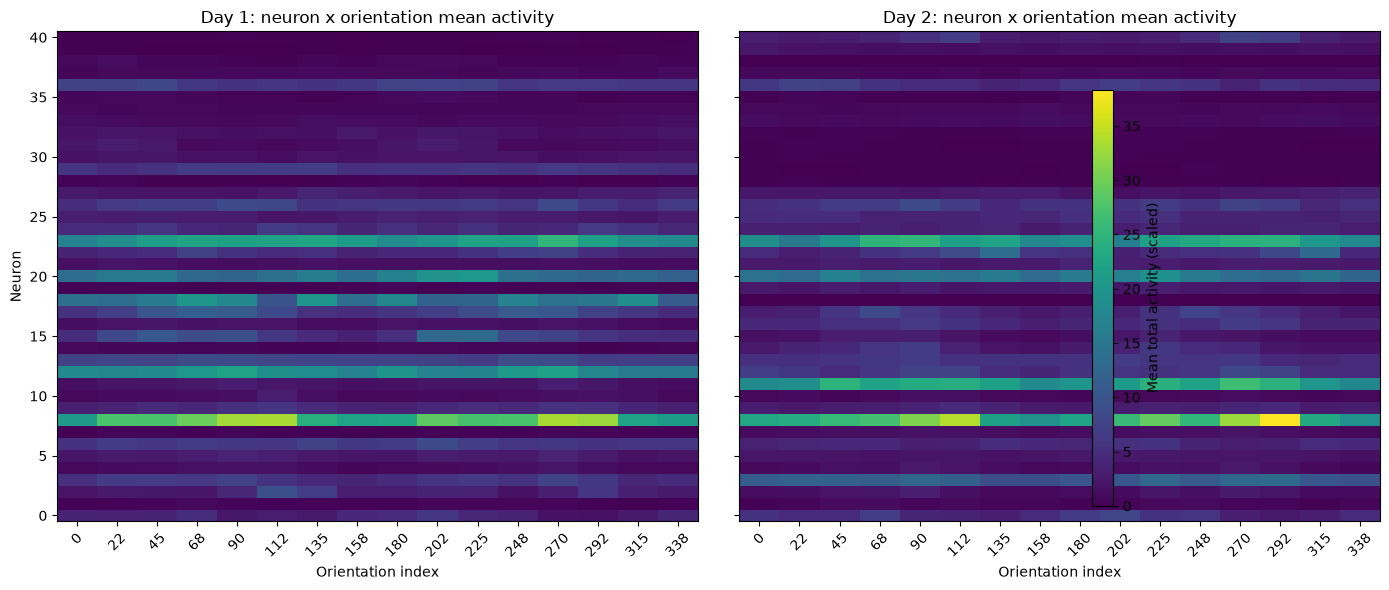

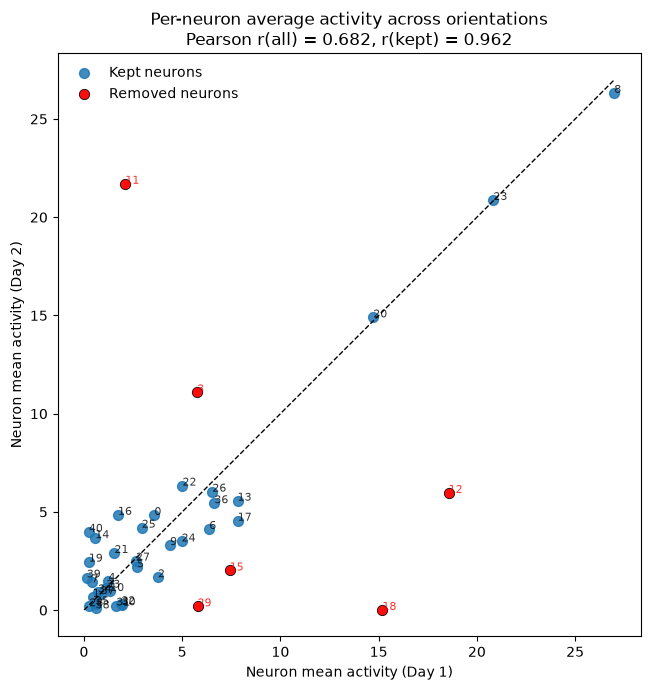

In [191]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Try common visual file names for each day.
day1_candidates = [
    'visual_day1_registered.npz',
]
day2_candidates = [
    'visual_day2_registered.npz',
]

def load_first_existing_npz(base_path, candidates):
    for name in candidates:
        fpath = os.path.join(base_path, name)
        if os.path.exists(fpath):
            return np.load(fpath, allow_pickle=True), fpath
    raise FileNotFoundError(f'None of these files found: {candidates}')

z_day1, day1_path = load_first_existing_npz(data_path, day1_candidates)
z_day2, day2_path = load_first_existing_npz(data_path, day2_candidates)

print('Loaded day 1 file:', day1_path)
print('Loaded day 2 file:', day2_path)

def compute_orientation_neuron_matrix(zfile, scale_factor=6 / 5):
    responses = zfile['responses']  # trials x neurons x time
    orientations = zfile['orientation']

    valid_orientations = np.unique(orientations[~np.isnan(orientations)])

    # Total activity per trial per neuron (sum over time bins), scaled to 600 ms equivalent.
    total_activity = responses.sum(axis=-1) * scale_factor

    mean_by_orientation = []
    for orientation_deg in valid_orientations:
        omask = np.isclose(orientations, orientation_deg)
        mean_by_orientation.append(total_activity[omask].mean(axis=0))

    # Shape: orientations x neurons -> transpose to neurons x orientations for plotting.
    matrix = np.vstack(mean_by_orientation).T
    return matrix, valid_orientations

mat_day1, ori_day1 = compute_orientation_neuron_matrix(z_day1)
mat_day2, ori_day2 = compute_orientation_neuron_matrix(z_day2)

# Use a shared color scale for direct visual comparison across days.
vmin = min(mat_day1.min(), mat_day2.min())
vmax = max(mat_day1.max(), mat_day2.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

im0 = axes[0].imshow(mat_day1, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Day 1: neuron x orientation mean activity')
axes[0].set_xlabel('Orientation index')
axes[0].set_ylabel('Neuron')
axes[0].set_xticks(np.arange(len(ori_day1)))
axes[0].set_xticklabels([f'{x:.0f}' for x in ori_day1], rotation=45)

im1 = axes[1].imshow(mat_day2, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('Day 2: neuron x orientation mean activity')
axes[1].set_xlabel('Orientation index')
axes[1].set_xticks(np.arange(len(ori_day2)))
axes[1].set_xticklabels([f'{x:.0f}' for x in ori_day2], rotation=45)

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label('Mean total activity (scaled)')

fig.tight_layout()

# Scatter plot: per-neuron average activity across orientations (Day 1 vs Day 2).
mean_day1_per_neuron = mat_day1.mean(axis=1)
mean_day2_per_neuron = mat_day2.mean(axis=1)
neuron_ids = np.arange(mean_day1_per_neuron.shape[0])

if 'OUTLIER_NEURON_IDS' in globals():
    outlier_ids = np.asarray(OUTLIER_NEURON_IDS, dtype=int)
else:
    residual = np.abs(mean_day2_per_neuron - mean_day1_per_neuron)
    outlier_ids = np.argsort(residual)[-6:]

outlier_mask = np.zeros_like(neuron_ids, dtype=bool)
outlier_mask[outlier_ids] = True
keep_mask = ~outlier_mask

r_all = np.corrcoef(mean_day1_per_neuron, mean_day2_per_neuron)[0, 1]
r_kept = np.corrcoef(mean_day1_per_neuron[keep_mask], mean_day2_per_neuron[keep_mask])[0, 1]

min_val = min(mean_day1_per_neuron.min(), mean_day2_per_neuron.min())
max_val = max(mean_day1_per_neuron.max(), mean_day2_per_neuron.max())

fig2, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    mean_day1_per_neuron[keep_mask],
    mean_day2_per_neuron[keep_mask],
    s=50,
    alpha=0.85,
    color='tab:blue',
    label='Kept neurons',
)
ax.scatter(
    mean_day1_per_neuron[outlier_mask],
    mean_day2_per_neuron[outlier_mask],
    s=55,
    alpha=0.95,
    color='red',
    edgecolors='black',
    linewidths=0.6,
    label='Removed neurons',
)
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black', linewidth=1)

for nid in neuron_ids:
    txt_color = 'red' if outlier_mask[nid] else 'black'
    ax.text(mean_day1_per_neuron[nid], mean_day2_per_neuron[nid], str(nid), fontsize=8, alpha=0.8, color=txt_color)

ax.set_xlabel('Neuron mean activity (Day 1)')
ax.set_ylabel('Neuron mean activity (Day 2)')
ax.set_title(
    f'Per-neuron average activity across orientations\n'
    f'Pearson r(all) = {r_all:.3f}, r(kept) = {r_kept:.3f}'
)
ax.legend(frameon=False)
ax.set_aspect('equal', adjustable='box')
fig2.tight_layout()

print('Highlighted removed neuron IDs:', np.sort(outlier_ids))

Neurons included in histogram: 41
Mean row correlation: 0.587
Median row correlation: 0.662


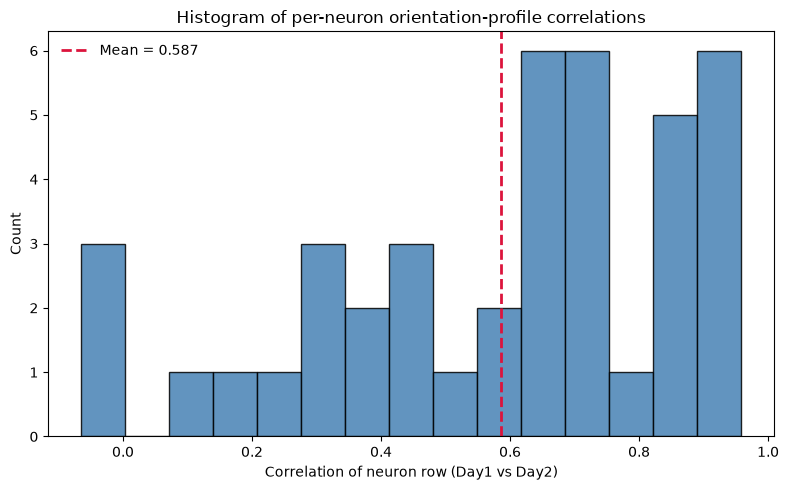

In [192]:
# Histogram of per-neuron row correlations across orientations (Day 1 vs Day 2).
# Each row is a neuron's tuning profile across orientation bins.
row_corrs = np.array([
    np.corrcoef(mat_day1[i, :], mat_day2[i, :])[0, 1]
    for i in range(mat_day1.shape[0])
])

valid_corrs = row_corrs[~np.isnan(row_corrs)]

fig3, ax = plt.subplots(figsize=(8, 5))
ax.hist(valid_corrs, bins=15, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(np.mean(valid_corrs), color='crimson', linestyle='--', linewidth=2, label=f'Mean = {np.mean(valid_corrs):.3f}')
ax.set_xlabel('Correlation of neuron row (Day1 vs Day2)')
ax.set_ylabel('Count')
ax.set_title('Histogram of per-neuron orientation-profile correlations')
ax.legend(frameon=False)
fig3.tight_layout()

print(f'Neurons included in histogram: {valid_corrs.size}')
print(f'Mean row correlation: {np.mean(valid_corrs):.3f}')
print(f'Median row correlation: {np.median(valid_corrs):.3f}')

In [193]:
import numpy as np

# Outlier-neuron handling is centralized here so all downstream analyses use the same mask.
# This computes per-neuron Day1 vs Day2 mismatch and removes the top mismatched neurons.
data_path = '/Users/bhaishahster/Data/xie_lab/icms_150_june_26_2day_unit_registered_data/'
scale_factor = 6 / 5
n_outliers_to_remove = 6


def neuron_orientation_averaged_activity(zfile, scale_factor=6 / 5):
    responses = zfile['responses']  # trials x neurons x time
    orientations = zfile['orientation']

    valid_orientations = np.unique(orientations[~np.isnan(orientations)])
    total_activity = responses.sum(axis=-1) * scale_factor

    mean_by_orientation = []
    for orientation_deg in valid_orientations:
        omask = np.isclose(orientations, orientation_deg)
        mean_by_orientation.append(total_activity[omask].mean(axis=0))

    mean_by_orientation = np.vstack(mean_by_orientation)  # orientations x neurons
    return mean_by_orientation.mean(axis=0)  # neurons


z_day1_raw = np.load(data_path + '/visual_day1_registered.npz', allow_pickle=True)
z_day2_raw = np.load(data_path + '/visual_day2_registered.npz', allow_pickle=True)

mean_day1 = neuron_orientation_averaged_activity(z_day1_raw, scale_factor=scale_factor)
mean_day2 = neuron_orientation_averaged_activity(z_day2_raw, scale_factor=scale_factor)

identity_residual = np.abs(mean_day2 - mean_day1)
OUTLIER_NEURON_IDS = np.sort(np.argsort(identity_residual)[-n_outliers_to_remove:])
KEEP_NEURON_IDS = np.array([i for i in range(mean_day1.shape[0]) if i not in set(OUTLIER_NEURON_IDS)])


class NeuronFilteredNpz:
    def __init__(self, npz_obj, keep_neuron_ids):
        self._npz = npz_obj
        self._keep = np.asarray(keep_neuron_ids)

    def __getitem__(self, key):
        arr = self._npz[key]
        if key == 'responses' and isinstance(arr, np.ndarray) and arr.ndim == 3:
            return arr[:, self._keep, :]
        return arr

    def keys(self):
        return self._npz.keys()

    @property
    def files(self):
        return self._npz.files


def wrap_with_neuron_filter(npz_obj):
    return NeuronFilteredNpz(npz_obj, KEEP_NEURON_IDS)


print('Outlier neuron IDs removed globally:', OUTLIER_NEURON_IDS)
print('Kept neurons:', KEEP_NEURON_IDS.shape[0])

Outlier neuron IDs removed globally: [ 3 11 12 15 18 29]
Kept neurons: 35


In [194]:
data_path = '/Users/bhaishahster/Data/xie_lab/icms_150_june_26_2day_unit_registered_data/'

import numpy as np
raw_y = np.load(data_path + '/electrical_day2_registered.npz', allow_pickle=True)
y = wrap_with_neuron_filter(raw_y) if 'wrap_with_neuron_filter' in globals() else raw_y
y['responses']        # (trials, kept units, 60) after optional neuron filtering
y['condition']        # 'oracle' / 'random' / 'generated' per trial
y['target_orientation_deg']  # generated trials only, else NaN
y.files               # list every array in the file



['responses',
 'pattern_name',
 'condition',
 'trial',
 'target_orientation_deg',
 'source_budget',
 'ori_idx',
 'decomp_method',
 'onset_timestamp',
 'common_idx',
 'day1_unit',
 'day2_unit',
 'bin_ms',
 'window_ms',
 'sample_rate']

In [203]:

import numpy as np

# day 2
raw_z_day2 = np.load(data_path + '/visual_day2_registered.npz', allow_pickle=True)
z_day2 = wrap_with_neuron_filter(raw_z_day2) if 'wrap_with_neuron_filter' in globals() else raw_z_day2
z_day2['responses']        # (trials, kept units, 60) after optional neuron filtering
z_day2['orientation']  # generated trials only, else NaN
z_day2.files               # list every array in the file


# day 1
raw_z_day1 = np.load(data_path + '/visual_day1_registered.npz', allow_pickle=True)
z_day1 = wrap_with_neuron_filter(raw_z_day1) if 'wrap_with_neuron_filter' in globals() else raw_z_day1
z_day1['responses']        # (trials, kept units, 60) after optional neuron filtering
z_day1['orientation']  # generated trials only, else NaN
z_day1.files               # list every array in the file

z_day_reference = z_day1
z_day_comparison = z_day2

In [196]:
z_day1['responses'].shape

(1600, 35, 50)

Orientation: 0.0 deg
Reference trials: 100
Comparison trials: 100


/var/folders/jm/7nh880sn3qvddfzmrm6_h5rh0000gp/T/ipykernel_50635/4121165013.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


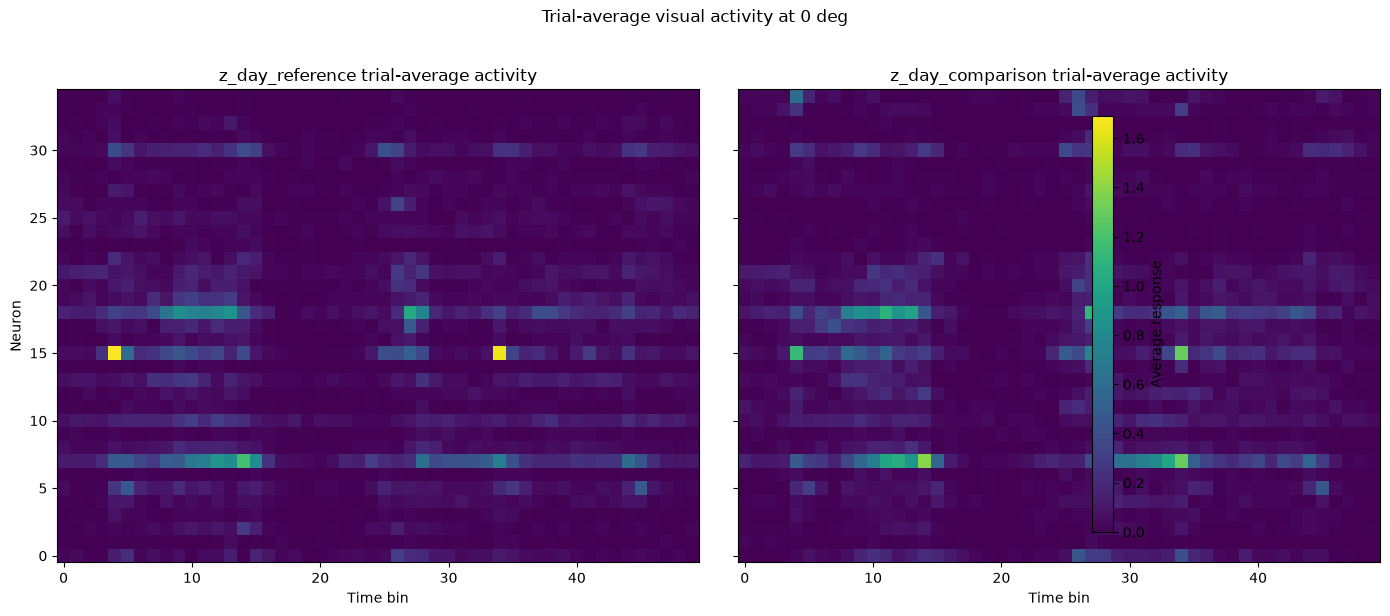

In [204]:
import numpy as np
import matplotlib.pyplot as plt

responses_ref = z_day_reference['responses']
orientations_ref = z_day_reference['orientation']
responses_cmp = z_day_comparison['responses']
orientations_cmp = z_day_comparison['orientation']

valid_ref = np.unique(orientations_ref[~np.isnan(orientations_ref)])
valid_cmp = np.unique(orientations_cmp[~np.isnan(orientations_cmp)])
common_orientations = np.intersect1d(valid_ref, valid_cmp)

if common_orientations.size == 0:
    raise ValueError('No shared orientations between z_day_reference and z_day_comparison.')

target_orientation_deg = common_orientations[0]

trial_mask_ref = np.isclose(orientations_ref, target_orientation_deg)
trial_mask_cmp = np.isclose(orientations_cmp, target_orientation_deg)

avg_response_ref = responses_ref[trial_mask_ref].mean(axis=0)
avg_response_cmp = responses_cmp[trial_mask_cmp].mean(axis=0)

vmin = min(avg_response_ref.min(), avg_response_cmp.min())
vmax = max(avg_response_ref.max(), avg_response_cmp.max())

print(f'Orientation: {target_orientation_deg} deg')
print(f'Reference trials: {trial_mask_ref.sum()}')
print(f'Comparison trials: {trial_mask_cmp.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

im0 = axes[0].imshow(avg_response_ref, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('z_day_reference trial-average activity')
axes[0].set_xlabel('Time bin')
axes[0].set_ylabel('Neuron')

im1 = axes[1].imshow(avg_response_cmp, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('z_day_comparison trial-average activity')
axes[1].set_xlabel('Time bin')

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label('Average response')

fig.suptitle(f'Trial-average visual activity at {target_orientation_deg:.0f} deg', y=1.02)
fig.tight_layout()

Orientations used: [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5]
Regression fit R^2 on train orientation means: 1.000


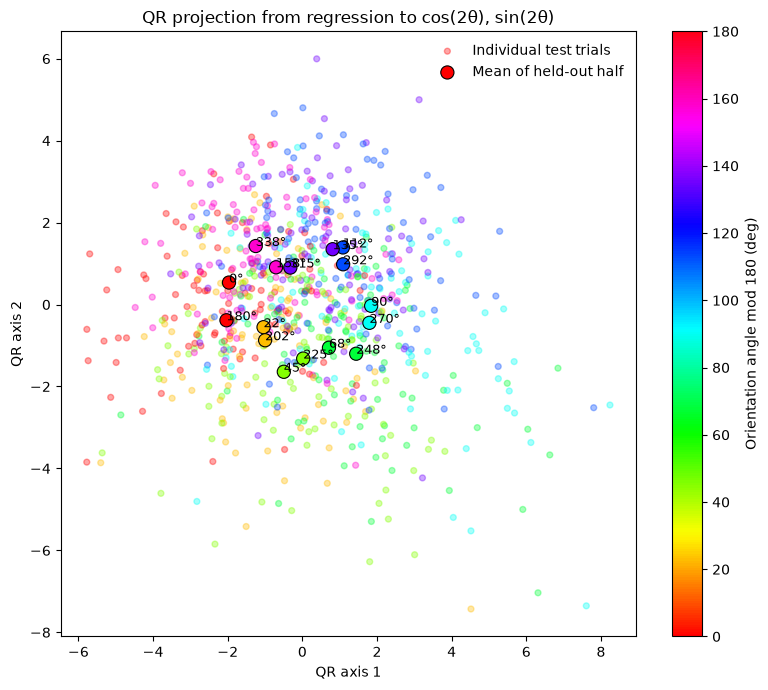

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

responses = z_day_reference['responses']
orientations = z_day_reference['orientation']

valid_orientations = np.unique(orientations[~np.isnan(orientations)])
rng = np.random.default_rng(0)
scale_factor = 4 / 5

train_vectors = []
test_vectors = []
used_orientations = []
all_test_points = []
all_test_labels = []

for orientation_deg in valid_orientations:
    trial_indices = np.flatnonzero(np.isclose(orientations, orientation_deg))
    if trial_indices.size < 2:
        continue

    shuffled_indices = rng.permutation(trial_indices)
    split_index = shuffled_indices.size // 2
    train_idx = shuffled_indices[:split_index]
    test_idx = shuffled_indices[split_index:]

    train_total_activity = responses[train_idx].sum(axis=-1) * scale_factor
    test_total_activity = responses[test_idx].sum(axis=-1) * scale_factor

    train_vectors.append(train_total_activity.mean(axis=0))
    test_vectors.append(test_total_activity.mean(axis=0))
    used_orientations.append(orientation_deg)

    all_test_points.append(test_total_activity)
    all_test_labels.append(np.full(test_total_activity.shape[0], orientation_deg))

train_vectors = np.vstack(train_vectors)
test_vectors = np.vstack(test_vectors)
used_orientations = np.asarray(used_orientations)
all_test_points = np.vstack(all_test_points)
all_test_labels = np.concatenate(all_test_labels)
all_test_labels_mod = np.mod(all_test_labels, 180)
used_orientations_mod = np.mod(used_orientations, 180)

# Mean-center each split before fitting/projection.
train_vectors_centered = train_vectors - train_vectors.mean(axis=0, keepdims=True)
test_vectors_centered = test_vectors - test_vectors.mean(axis=0, keepdims=True)
all_test_points_centered = all_test_points - all_test_points.mean(axis=0, keepdims=True)

theta_rad = np.deg2rad(2 * used_orientations)
regression_targets = np.column_stack([np.cos(theta_rad), np.sin(theta_rad)])

# Learn neuron-to-target regression, then orthonormalize its 2D subspace with QR.
regression_matrix, *_ = np.linalg.lstsq(train_vectors_centered, regression_targets, rcond=None)
projection_basis, _ = np.linalg.qr(regression_matrix)
projection_basis = projection_basis[:, :2]

test_projection = test_vectors_centered @ projection_basis
individual_test_projection = all_test_points_centered @ projection_basis

prediction_on_train = train_vectors_centered @ regression_matrix
fit_r2 = 1 - np.sum((regression_targets - prediction_on_train) ** 2) / np.sum(
    (regression_targets - regression_targets.mean(axis=0)) ** 2
)

print('Orientations used:', used_orientations)
print(f'Regression fit R^2 on train orientation means: {fit_r2:.3f}')

cmap = plt.cm.hsv
norm = Normalize(vmin=0, vmax=180)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    individual_test_projection[:, 0],
    individual_test_projection[:, 1],
    c=all_test_labels_mod,
    cmap=cmap,
    norm=norm,
    s=18,
    alpha=0.35,
    label='Individual test trials',
)
ax.scatter(
    test_projection[:, 0],
    test_projection[:, 1],
    c=used_orientations_mod,
    cmap=cmap,
    norm=norm,
    s=90,
    edgecolors='black',
    linewidths=0.8,
    label='Mean of held-out half',
)

for idx, orientation_deg in enumerate(used_orientations):
    ax.text(test_projection[idx, 0], test_projection[idx, 1], f'{orientation_deg:.0f}°', fontsize=9)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colorbar = fig.colorbar(sm, ax=ax)
colorbar.set_label('Orientation angle mod 180 (deg)')

ax.set_xlabel('QR axis 1')
ax.set_ylabel('QR axis 2')
ax.set_title('QR projection from regression to cos(2θ), sin(2θ)')
ax.legend(frameon=False)
fig.tight_layout()


Visual orientation means (test half): 16
Electrical mean points: 16
Electrical single trials: 313


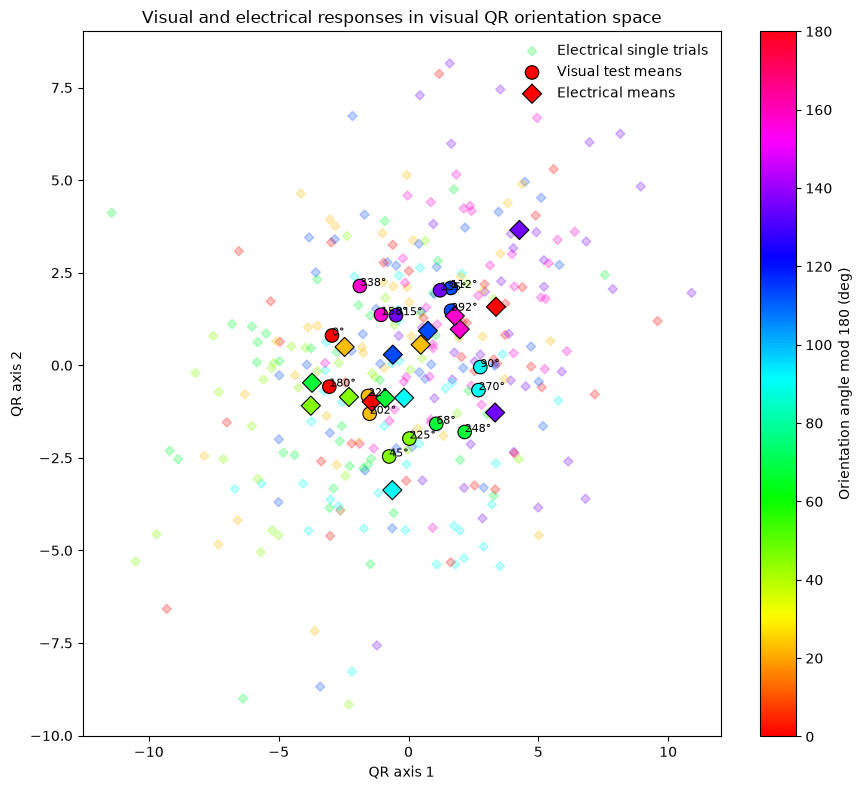

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ---------- Build visual projection space (train on half, evaluate on held-out half) ----------
visual_responses = z_day_reference['responses']
visual_orientations = z_day_reference['orientation']

valid_visual_orientations = np.unique(visual_orientations[~np.isnan(visual_orientations)])
rng = np.random.default_rng(0)
scale_factor = 6 / 5

visual_train_vectors = []
visual_test_vectors = []
used_visual_orientations = []

for orientation_deg in valid_visual_orientations:
    trial_indices = np.flatnonzero(np.isclose(visual_orientations, orientation_deg))
    if trial_indices.size < 2:
        continue

    shuffled_indices = rng.permutation(trial_indices)
    split_index = shuffled_indices.size // 2
    train_idx = shuffled_indices[:split_index]
    test_idx = shuffled_indices[split_index:]

    train_total_activity = visual_responses[train_idx].sum(axis=-1) * scale_factor
    test_total_activity = visual_responses[test_idx].sum(axis=-1) * scale_factor

    visual_train_vectors.append(train_total_activity.mean(axis=0))
    visual_test_vectors.append(test_total_activity.mean(axis=0))
    used_visual_orientations.append(orientation_deg)

visual_train_vectors = np.vstack(visual_train_vectors)
visual_test_vectors = np.vstack(visual_test_vectors)
used_visual_orientations = np.asarray(used_visual_orientations)

# Mean-center before fitting and before applying the projection.
visual_train_centered = visual_train_vectors - visual_train_vectors.mean(axis=0, keepdims=True)
visual_test_centered = visual_test_vectors - visual_test_vectors.mean(axis=0, keepdims=True)

theta_rad = np.deg2rad(2 * used_visual_orientations)
regression_targets = np.column_stack([np.cos(theta_rad), np.sin(theta_rad)])
regression_matrix, *_ = np.linalg.lstsq(visual_train_centered, regression_targets, rcond=None)
projection_basis, _ = np.linalg.qr(regression_matrix)
projection_basis = projection_basis[:, :2]

visual_test_projection = visual_test_centered @ projection_basis

# ---------- Select electrical generated/pca/budget10 trials ----------
electrical_responses = y['responses']
electrical_target_orientation = y['target_orientation_deg']

def _to_lower_str(arr):
    return np.char.lower(np.asarray(arr).astype(str))

condition = _to_lower_str(y['condition'])
decomp_method = _to_lower_str(y['decomp_method'])
source_budget = np.asarray(y['source_budget'])

electrical_mask = (
    (source_budget == 10)
    & (condition == 'generated')
    & (decomp_method == 'lda')
    & ~np.isnan(electrical_target_orientation)
)

electrical_single_trial_totals = electrical_responses[electrical_mask].sum(axis=-1) * scale_factor
electrical_single_trial_orientation = electrical_target_orientation[electrical_mask]

if electrical_single_trial_totals.shape[0] == 0:
    raise ValueError('No electrical trials match source_budget==10, decomp_method==pca, condition==generated.')

# Mean-center electrical responses before projection.
electrical_single_trial_centered = electrical_single_trial_totals - electrical_single_trial_totals.mean(axis=0, keepdims=True)
electrical_single_projection = electrical_single_trial_centered @ projection_basis

electrical_mean_vectors = []
electrical_mean_orientations = []
for orientation_deg in np.unique(electrical_single_trial_orientation):
    orient_mask = np.isclose(electrical_single_trial_orientation, orientation_deg)
    electrical_mean_vectors.append(electrical_single_trial_totals[orient_mask].mean(axis=0))
    electrical_mean_orientations.append(orientation_deg)

electrical_mean_vectors = np.vstack(electrical_mean_vectors)
electrical_mean_orientations = np.asarray(electrical_mean_orientations)
electrical_mean_centered = electrical_mean_vectors - electrical_mean_vectors.mean(axis=0, keepdims=True)
electrical_mean_projection = electrical_mean_centered @ projection_basis

# ---------- Plot visual means + electrical means/single trials ----------
visual_colors = np.mod(used_visual_orientations, 180)
electrical_single_colors = np.mod(electrical_single_trial_orientation, 180)
electrical_mean_colors = np.mod(electrical_mean_orientations, 180)

cmap = plt.cm.hsv
norm = Normalize(vmin=0, vmax=180)

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    electrical_single_projection[:, 0],
    electrical_single_projection[:, 1],
    c=electrical_single_colors,
    cmap=cmap,
    norm=norm,
    marker='D',
    s=22,
    alpha=0.25,
    label='Electrical single trials',
)
ax.scatter(
    visual_test_projection[:, 0],
    visual_test_projection[:, 1],
    c=visual_colors,
    cmap=cmap,
    norm=norm,
    marker='o',
    s=95,
    edgecolors='black',
    linewidths=0.8,
    label='Visual test means',
)
ax.scatter(
    electrical_mean_projection[:, 0],
    electrical_mean_projection[:, 1],
    c=electrical_mean_colors,
    cmap=cmap,
    norm=norm,
    marker='D',
    s=95,
    edgecolors='black',
    linewidths=0.8,
    label='Electrical means',
)

for idx, orientation_deg in enumerate(used_visual_orientations):
    ax.text(visual_test_projection[idx, 0], visual_test_projection[idx, 1], f'{orientation_deg:.0f}°', fontsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colorbar = fig.colorbar(sm, ax=ax)
colorbar.set_label('Orientation angle mod 180 (deg)')

ax.set_xlabel('QR axis 1')
ax.set_ylabel('QR axis 2')
ax.set_title('Visual and electrical responses in visual QR orientation space')
ax.legend(frameon=False)
fig.tight_layout()

print('Visual orientation means (test half):', visual_test_projection.shape[0])
print('Electrical mean points:', electrical_mean_projection.shape[0])
print('Electrical single trials:', electrical_single_projection.shape[0])


[PCA] budgets plotted: [ 4.  6.  8. 10.]
[LDA] budgets plotted: [ 4.  6.  8. 10.]
Shared visual orientations: [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5]
Difference-PC1 explained variance ratio: 0.4108185004147191
Reference PCA explained variance ratio: [0.37608871 0.10682926]


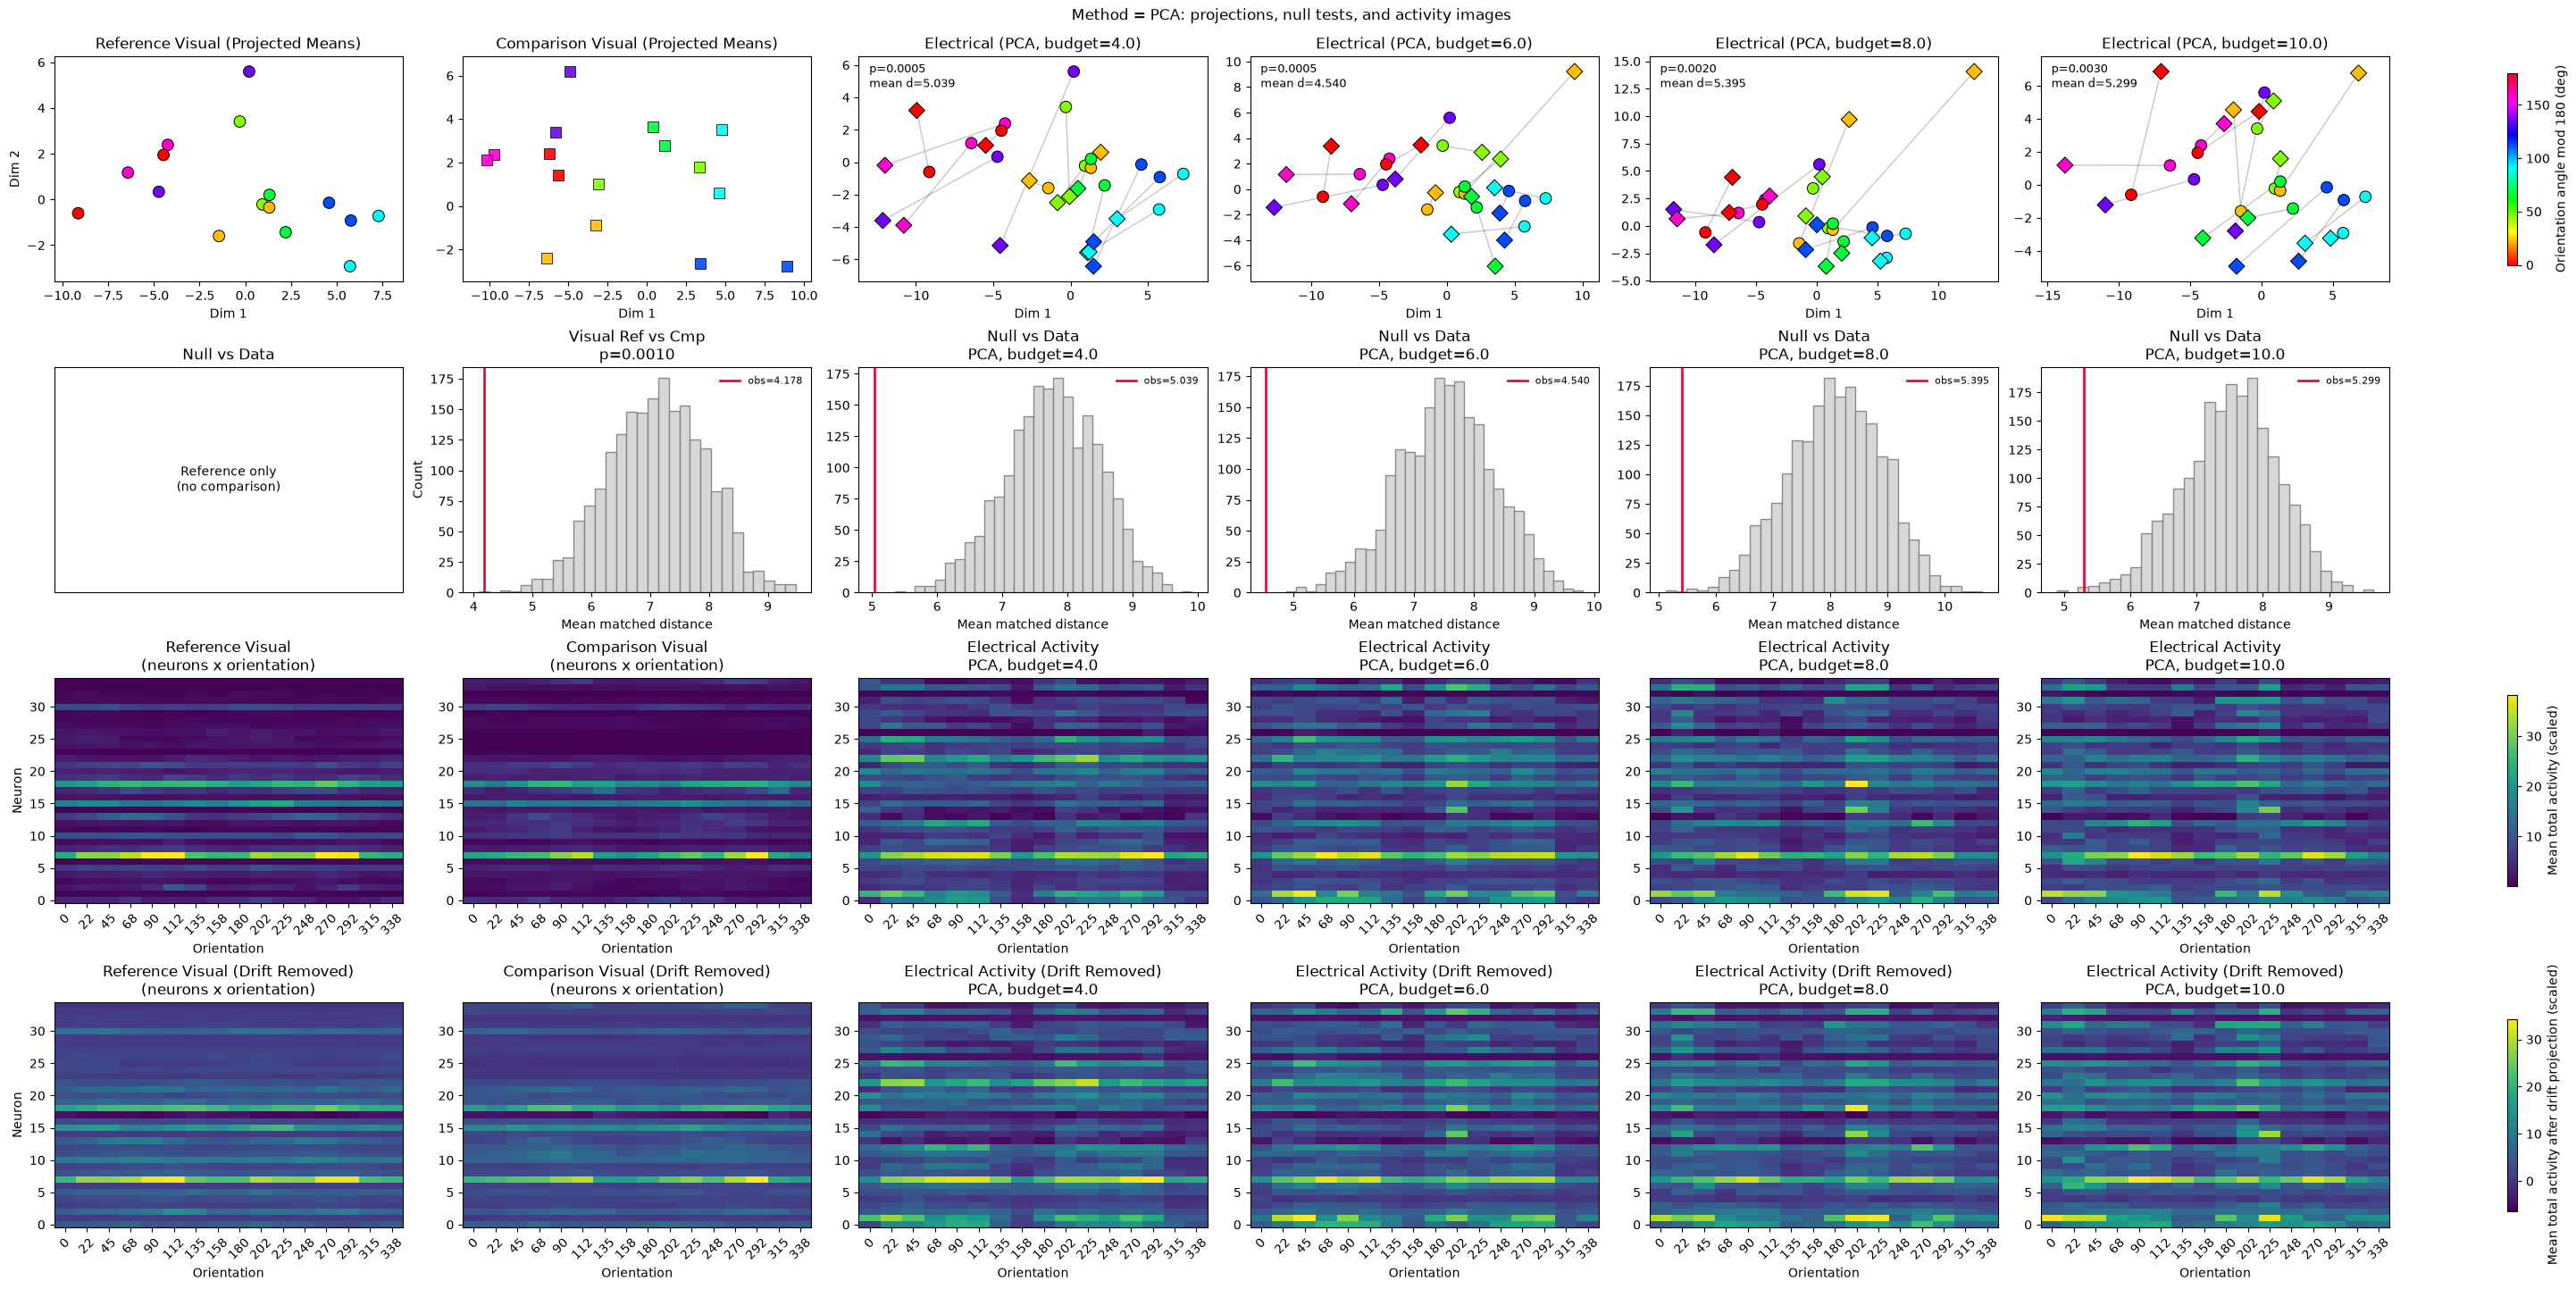

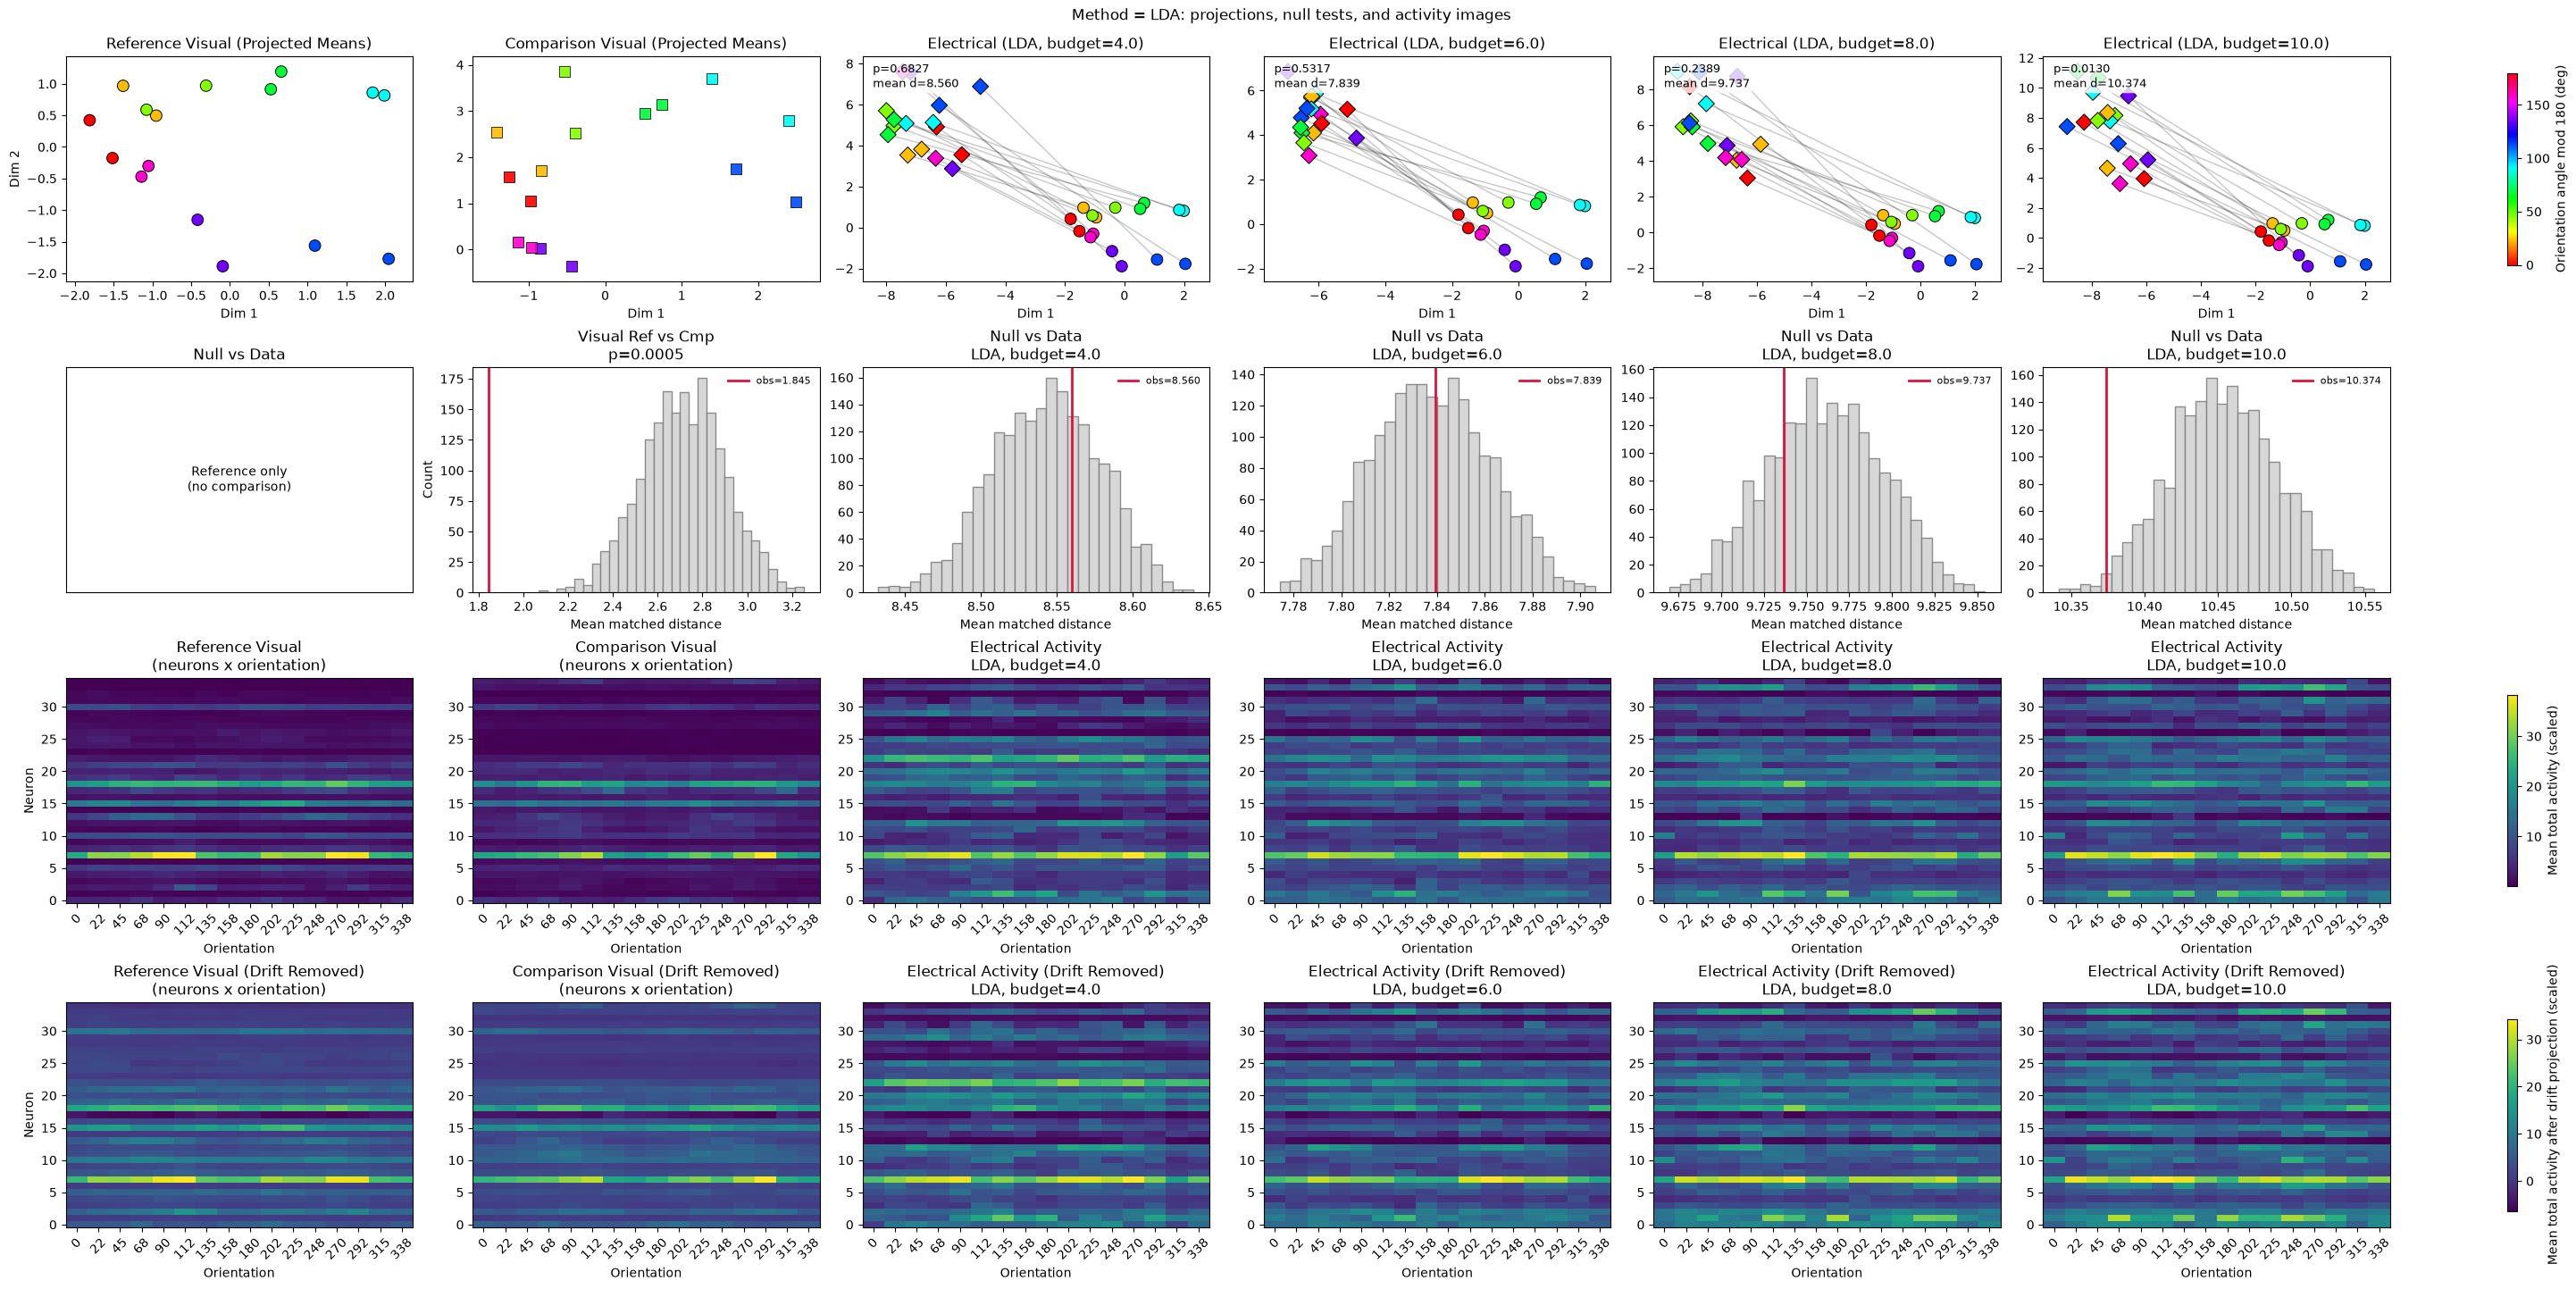

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def build_train_test_activity(zfile, rng, scale_factor):
    responses = zfile['responses']
    orientations = zfile['orientation']

    valid_orientations = np.unique(orientations[~np.isnan(orientations)])
    train_means = []
    test_means = []
    train_single_activity = []
    train_single_orientations = []
    test_single_activity = []
    test_single_orientations = []
    used_orientations = []

    for orientation_deg in valid_orientations:
        trial_indices = np.flatnonzero(np.isclose(orientations, orientation_deg))
        if trial_indices.size < 2:
            continue

        shuffled_indices = rng.permutation(trial_indices)
        split_index = shuffled_indices.size // 2
        train_idx = shuffled_indices[:split_index]
        test_idx = shuffled_indices[split_index:]

        train_total_activity = responses[train_idx].sum(axis=-1) * scale_factor
        test_total_activity = responses[test_idx].sum(axis=-1) * scale_factor

        train_means.append(train_total_activity.mean(axis=0))
        test_means.append(test_total_activity.mean(axis=0))
        train_single_activity.append(train_total_activity)
        train_single_orientations.append(np.full(train_total_activity.shape[0], orientation_deg))
        test_single_activity.append(test_total_activity)
        test_single_orientations.append(np.full(test_total_activity.shape[0], orientation_deg))
        used_orientations.append(orientation_deg)

    if len(train_means) == 0:
        raise ValueError('No valid orientation means could be constructed.')

    return {
        'train_means': np.vstack(train_means),
        'test_means': np.vstack(test_means),
        'train_single_activity': np.vstack(train_single_activity),
        'train_single_orientations': np.concatenate(train_single_orientations),
        'test_single_activity': np.vstack(test_single_activity),
        'test_single_orientations': np.concatenate(test_single_orientations),
        'used_orientations': np.asarray(used_orientations),
    }


def remove_component(X, direction):
    return X - np.outer(X @ direction, direction)


def set_tight_limits(ax, points, pad_frac=0.08, min_span=1e-6):
    if points.shape[0] == 0:
        return

    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    xspan = max(xmax - xmin, min_span)
    yspan = max(ymax - ymin, min_span)

    ax.set_xlim(xmin - pad_frac * xspan, xmax + pad_frac * xspan)
    ax.set_ylim(ymin - pad_frac * yspan, ymax + pad_frac * yspan)


def orientation_neuron_image(totals, orientations, target_orientations):
    # Returns image as neurons x orientations, with NaN where an orientation is missing.
    n_neurons = totals.shape[1]
    image = np.full((n_neurons, target_orientations.size), np.nan)
    for i, ori in enumerate(target_orientations):
        mask = np.isclose(orientations, ori)
        if np.any(mask):
            image[:, i] = totals[mask].mean(axis=0)
    return image


if 'z_day_reference' not in globals() or 'z_day_comparison' not in globals():
    raise ValueError('z_day_reference and z_day_comparison must both be defined.')

rng = np.random.default_rng(0)
scale_factor = 6 / 5
n_null_shuffles = 2000

# ---------- Visual means for plotting ----------
ref_sets = build_train_test_activity(z_day_reference, rng, scale_factor)
cmp_sets = build_train_test_activity(z_day_comparison, rng, scale_factor)

common_visual_orientations = np.intersect1d(ref_sets['used_orientations'], cmp_sets['used_orientations'])
if common_visual_orientations.size < 2:
    raise ValueError('Need at least 2 shared orientations between z_day_reference and z_day_comparison.')

ref_idx = np.array([np.flatnonzero(np.isclose(ref_sets['used_orientations'], ang))[0] for ang in common_visual_orientations])
cmp_idx = np.array([np.flatnonzero(np.isclose(cmp_sets['used_orientations'], ang))[0] for ang in common_visual_orientations])

ref_train_vectors = ref_sets['train_means'][ref_idx]
ref_test_vectors = ref_sets['test_means'][ref_idx]
cmp_train_vectors = cmp_sets['train_means'][cmp_idx]
cmp_test_vectors = cmp_sets['test_means'][cmp_idx]

# ---------- Remove day-shift direction ----------
diff_vectors = cmp_train_vectors - ref_train_vectors
diff_pca = PCA(n_components=1, random_state=0)
diff_pca.fit(diff_vectors)
diff_direction = diff_pca.components_[0]
diff_direction = diff_direction / np.linalg.norm(diff_direction)

ref_train_ortho = remove_component(ref_train_vectors, diff_direction)
ref_test_ortho = remove_component(ref_test_vectors, diff_direction)
cmp_test_ortho = remove_component(cmp_test_vectors, diff_direction)

# ---------- Fit spaces from single-trial reference activity ----------
ref_train_single_activity = ref_sets['train_single_activity']
ref_train_single_orientations = ref_sets['train_single_orientations']
ref_train_single_ortho = remove_component(ref_train_single_activity, diff_direction)

pca_model = PCA(n_components=2, random_state=0)
pca_model.fit(ref_train_single_ortho)
ref_proj_pca = pca_model.transform(ref_test_ortho)
cmp_proj_pca = pca_model.transform(cmp_test_ortho)

lda_targets_mod_single = np.mod(ref_train_single_orientations, 180)
lda_unique_single = np.sort(np.unique(lda_targets_mod_single))
lda_targets_single = np.searchsorted(lda_unique_single, lda_targets_mod_single)
lda_model = LinearDiscriminantAnalysis(n_components=2)
lda_model.fit(ref_train_single_ortho, lda_targets_single)
ref_proj_lda = lda_model.transform(ref_test_ortho)
cmp_proj_lda = lda_model.transform(cmp_test_ortho)

projection_models = {'pca': pca_model, 'lda': lda_model}
visual_projections_ref = {'pca': ref_proj_pca, 'lda': ref_proj_lda}
visual_projections_cmp = {'pca': cmp_proj_pca, 'lda': cmp_proj_lda}

# ---------- Matrices for image rows ----------
ref_totals = z_day_reference['responses'].sum(axis=-1) * scale_factor
ref_oris = z_day_reference['orientation']
cmp_totals = z_day_comparison['responses'].sum(axis=-1) * scale_factor
cmp_oris = z_day_comparison['orientation']

ref_totals_valid = ref_totals[~np.isnan(ref_oris)]
ref_oris_valid = ref_oris[~np.isnan(ref_oris)]
cmp_totals_valid = cmp_totals[~np.isnan(cmp_oris)]
cmp_oris_valid = cmp_oris[~np.isnan(cmp_oris)]

ref_img = orientation_neuron_image(ref_totals_valid, ref_oris_valid, common_visual_orientations)
cmp_img = orientation_neuron_image(cmp_totals_valid, cmp_oris_valid, common_visual_orientations)

# New 4th row: activity images after projecting out drift direction.
ref_totals_ortho = remove_component(ref_totals_valid, diff_direction)
cmp_totals_ortho = remove_component(cmp_totals_valid, diff_direction)
ref_img_ortho = orientation_neuron_image(ref_totals_ortho, ref_oris_valid, common_visual_orientations)
cmp_img_ortho = orientation_neuron_image(cmp_totals_ortho, cmp_oris_valid, common_visual_orientations)

# ---------- Electrical metadata ----------
def _to_lower_str(arr):
    return np.char.lower(np.asarray(arr).astype(str))

condition = _to_lower_str(y['condition'])
decomp_method = _to_lower_str(y['decomp_method'])
source_budget = np.asarray(y['source_budget'])
electrical_target_orientation = np.asarray(y['target_orientation_deg'])
electrical_responses = y['responses']
base_mask = (condition == 'generated') & ~np.isnan(electrical_target_orientation)

methods = ['pca', 'lda']
cmap = plt.cm.hsv
norm = Normalize(vmin=0, vmax=180)
visual_colors = np.mod(common_visual_orientations, 180)

for method in methods:
    budgets = np.sort(np.unique(source_budget[base_mask & (decomp_method == method)]))
    if budgets.size == 0:
        print(f'No budgets found for method={method}. Skipping figure.')
        continue

    ncols = 2 + len(budgets)
    fig, axes = plt.subplots(4, ncols, figsize=(4.8 * ncols, 14), constrained_layout=True)

    ref_proj = visual_projections_ref[method]
    cmp_proj = visual_projections_cmp[method]
    projector = projection_models[method]

    # Row 1, Col 0: reference visual projection
    ax = axes[0, 0]
    ax.scatter(ref_proj[:, 0], ref_proj[:, 1], c=visual_colors, cmap=cmap, norm=norm,
               marker='o', s=85, edgecolors='black', linewidths=0.7)
    ax.set_title('Reference Visual (Projected Means)')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    set_tight_limits(ax, ref_proj)

    # Row 1, Col 1: comparison visual projection
    ax = axes[0, 1]
    ax.scatter(cmp_proj[:, 0], cmp_proj[:, 1], c=visual_colors, cmap=cmap, norm=norm,
               marker='s', s=75, edgecolors='black', linewidths=0.6, alpha=0.9)
    ax.set_title('Comparison Visual (Projected Means)')
    ax.set_xlabel('Dim 1')
    set_tight_limits(ax, cmp_proj)

    # Row 2, Col 0: no null test for standalone reference
    ax = axes[1, 0]
    ax.text(0.5, 0.5, 'Reference only\n(no comparison)', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Null vs Data')
    ax.set_xticks([])
    ax.set_yticks([])

    # Row 2, Col 1: visual ref vs visual cmp null test
    obs_dist_vis = np.mean(np.linalg.norm(ref_proj - cmp_proj, axis=1))
    null_dist_vis = np.empty(n_null_shuffles)
    for s in range(n_null_shuffles):
        perm = rng.permutation(ref_proj.shape[0])
        null_dist_vis[s] = np.mean(np.linalg.norm(ref_proj - cmp_proj[perm], axis=1))
    p_value_vis = (1 + np.sum(null_dist_vis <= obs_dist_vis)) / (n_null_shuffles + 1)

    ax = axes[1, 1]
    ax.hist(null_dist_vis, bins=30, color='lightgray', edgecolor='gray', alpha=0.9)
    ax.axvline(obs_dist_vis, color='crimson', linewidth=2, label=f'obs={obs_dist_vis:.3f}')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.set_title(f'Visual Ref vs Cmp\np={p_value_vis:.4f}')
    ax.set_xlabel('Mean matched distance')
    ax.set_ylabel('Count')

    # Row 3, Col 0-1: raw visual activity images
    ax = axes[2, 0]
    im0 = ax.imshow(ref_img, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title('Reference Visual\n(neurons x orientation)')
    ax.set_xlabel('Orientation')
    ax.set_ylabel('Neuron')
    ax.set_xticks(np.arange(common_visual_orientations.size))
    ax.set_xticklabels([f'{x:.0f}' for x in common_visual_orientations], rotation=45)

    ax = axes[2, 1]
    im1 = ax.imshow(cmp_img, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title('Comparison Visual\n(neurons x orientation)')
    ax.set_xlabel('Orientation')
    ax.set_xticks(np.arange(common_visual_orientations.size))
    ax.set_xticklabels([f'{x:.0f}' for x in common_visual_orientations], rotation=45)

    # Row 4, Col 0-1: drift-projected visual activity images
    ax = axes[3, 0]
    im0d = ax.imshow(ref_img_ortho, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title('Reference Visual (Drift Removed)\n(neurons x orientation)')
    ax.set_xlabel('Orientation')
    ax.set_ylabel('Neuron')
    ax.set_xticks(np.arange(common_visual_orientations.size))
    ax.set_xticklabels([f'{x:.0f}' for x in common_visual_orientations], rotation=45)

    ax = axes[3, 1]
    im1d = ax.imshow(cmp_img_ortho, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title('Comparison Visual (Drift Removed)\n(neurons x orientation)')
    ax.set_xlabel('Orientation')
    ax.set_xticks(np.arange(common_visual_orientations.size))
    ax.set_xticklabels([f'{x:.0f}' for x in common_visual_orientations], rotation=45)

    for j, budget in enumerate(budgets, start=2):
        combo_mask = base_mask & (decomp_method == method) & (source_budget == budget)
        combo_oris = electrical_target_orientation[combo_mask]
        combo_trials = electrical_responses[combo_mask].sum(axis=-1) * scale_factor

        # Top row: electrical vs reference projection with matched-orientation lines
        ax_top = axes[0, j]
        ax_top.scatter(ref_proj[:, 0], ref_proj[:, 1], c=visual_colors, cmap=cmap, norm=norm,
                       marker='o', s=85, edgecolors='black', linewidths=0.7, label='Visual ref means')

        obs_dist = np.nan
        null_dist = None
        elec_projection = np.empty((0, 2))
        elec_mean_oris = np.array([])

        if combo_trials.shape[0] > 0:
            elec_mean_vectors = []
            elec_mean_oris_list = []
            for ori in np.unique(combo_oris):
                omask = np.isclose(combo_oris, ori)
                elec_mean_vectors.append(combo_trials[omask].mean(axis=0))
                elec_mean_oris_list.append(ori)

            elec_mean_vectors = np.vstack(elec_mean_vectors)
            elec_mean_oris = np.asarray(elec_mean_oris_list)
            elec_mean_ortho = remove_component(elec_mean_vectors, diff_direction)
            elec_projection = projector.transform(elec_mean_ortho)

            common_oris = np.intersect1d(common_visual_orientations, elec_mean_oris)
            for ori in common_oris:
                vi = np.flatnonzero(np.isclose(common_visual_orientations, ori))[0]
                ei = np.flatnonzero(np.isclose(elec_mean_oris, ori))[0]
                ax_top.plot(
                    [ref_proj[vi, 0], elec_projection[ei, 0]],
                    [ref_proj[vi, 1], elec_projection[ei, 1]],
                    color='black', alpha=0.22, linewidth=1.0, zorder=0,
                )

            ax_top.scatter(
                elec_projection[:, 0], elec_projection[:, 1],
                c=np.mod(elec_mean_oris, 180), cmap=cmap, norm=norm,
                marker='D', s=85, edgecolors='black', linewidths=0.7,
                label='Electrical means',
            )

            if common_oris.size >= 2:
                vis_pts = np.vstack([
                    ref_proj[np.flatnonzero(np.isclose(common_visual_orientations, ori))[0]]
                    for ori in common_oris
                ])
                elec_pts = np.vstack([
                    elec_projection[np.flatnonzero(np.isclose(elec_mean_oris, ori))[0]]
                    for ori in common_oris
                ])
                obs_dist = np.mean(np.linalg.norm(vis_pts - elec_pts, axis=1))

                null_dist = np.empty(n_null_shuffles)
                for s in range(n_null_shuffles):
                    perm = rng.permutation(common_oris.size)
                    null_dist[s] = np.mean(np.linalg.norm(vis_pts - elec_pts[perm], axis=1))

        p_value = np.nan
        if null_dist is not None and np.isfinite(obs_dist):
            p_value = (1 + np.sum(null_dist <= obs_dist)) / (n_null_shuffles + 1)

        ax_top.set_title(f'Electrical ({method.upper()}, budget={budget})')
        ax_top.set_xlabel('Dim 1')
        points_for_zoom = [ref_proj]
        if elec_projection.shape[0] > 0:
            points_for_zoom.append(elec_projection)
        set_tight_limits(ax_top, np.vstack(points_for_zoom))
        ann = f'p={p_value:.4f}\nmean d={obs_dist:.3f}' if np.isfinite(p_value) else 'p=NA\nmean d=NA'
        ax_top.text(
            0.03, 0.97, ann, transform=ax_top.transAxes,
            va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'),
        )

        # Row 2: null vs data histogram
        ax_hist = axes[1, j]
        if null_dist is not None and np.isfinite(obs_dist):
            ax_hist.hist(null_dist, bins=30, color='lightgray', edgecolor='gray', alpha=0.9)
            ax_hist.axvline(obs_dist, color='crimson', linewidth=2, label=f'obs={obs_dist:.3f}')
            ax_hist.legend(frameon=False, loc='best', fontsize=8)
        else:
            ax_hist.text(0.5, 0.5, 'No valid null', ha='center', va='center', transform=ax_hist.transAxes)
        ax_hist.set_title(f'Null vs Data\n{method.upper()}, budget={budget}')
        ax_hist.set_xlabel('Mean matched distance')

        # Row 3: electrical activity image (neurons x orientation)
        ax_img = axes[2, j]
        # Row 4: electrical activity image after drift removal
        ax_img_drift = axes[3, j]
        if combo_trials.shape[0] > 0:
            elec_img = orientation_neuron_image(combo_trials, combo_oris, common_visual_orientations)
            ax_img.imshow(elec_img, aspect='auto', origin='lower', cmap='viridis')

            combo_trials_ortho = remove_component(combo_trials, diff_direction)
            elec_img_ortho = orientation_neuron_image(combo_trials_ortho, combo_oris, common_visual_orientations)
            ax_img_drift.imshow(elec_img_ortho, aspect='auto', origin='lower', cmap='viridis')
        else:
            ax_img.text(0.5, 0.5, 'No electrical trials', ha='center', va='center', transform=ax_img.transAxes)
            ax_img_drift.text(0.5, 0.5, 'No electrical trials', ha='center', va='center', transform=ax_img_drift.transAxes)

        ax_img.set_title(f'Electrical Activity\n{method.upper()}, budget={budget}')
        ax_img.set_xlabel('Orientation')
        ax_img.set_xticks(np.arange(common_visual_orientations.size))
        ax_img.set_xticklabels([f'{x:.0f}' for x in common_visual_orientations], rotation=45)

        ax_img_drift.set_title(f'Electrical Activity (Drift Removed)\n{method.upper()}, budget={budget}')
        ax_img_drift.set_xlabel('Orientation')
        ax_img_drift.set_xticks(np.arange(common_visual_orientations.size))
        ax_img_drift.set_xticklabels([f'{x:.0f}' for x in common_visual_orientations], rotation=45)

    # Shared orientation colorbar for top row.
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_top = fig.colorbar(sm, ax=axes[0, :].ravel().tolist(), shrink=0.85)
    cbar_top.set_label('Orientation angle mod 180 (deg)')

    # Shared activity colorbars for rows 3 and 4.
    cbar_img = fig.colorbar(im1, ax=axes[2, :].ravel().tolist(), shrink=0.85)
    cbar_img.set_label('Mean total activity (scaled)')

    cbar_img_drift = fig.colorbar(im1d, ax=axes[3, :].ravel().tolist(), shrink=0.85)
    cbar_img_drift.set_label('Mean total activity after drift projection (scaled)')

    fig.suptitle(f'Method = {method.upper()}: projections, null tests, and activity images', y=1.02)

    print(f'[{method.upper()}] budgets plotted:', budgets)

print('Shared visual orientations:', common_visual_orientations)
print('Difference-PC1 explained variance ratio:', diff_pca.explained_variance_ratio_[0])
print('Reference PCA explained variance ratio:', pca_model.explained_variance_ratio_)

In [210]:
lda_targets_mod = np.mod(common_visual_orientations, 180)
lda_unique = np.sort(np.unique(lda_targets_mod))
lda_targets = np.searchsorted(lda_unique, lda_targets_mod)
lda_model = LinearDiscriminantAnalysis(n_components=2)

In [234]:
lda_targets

array([0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2, 3, 4, 5, 6, 7])

In [235]:
# Day 1 and Day 2 visual response comparison

In [237]:
orientation_avg_activity.shape

(16, 35, 50)

Gaussian smoothing sigma (bins): 5.0
Regression fit matrix shape (neurons x 2): (35, 2)
Projection basis shape (neurons x 2): (35, 2)
Target mean activity shape (neurons x time): (35, 50)
Smoothed target mean shape (neurons x time): (35, 50)
Projected time-course shape (time x 2): (50, 2)
Gaussian smoothing sigma (bins): 5.0
Regression fit matrix shape (neurons x 2): (35, 2)
Projection basis shape (neurons x 2): (35, 2)
Target mean activity shape (neurons x time): (35, 50)
Smoothed target mean shape (neurons x time): (35, 50)
Projected time-course shape (time x 2): (50, 2)
Gaussian smoothing sigma (bins): 5.0
Regression fit matrix shape (neurons x 2): (35, 2)
Projection basis shape (neurons x 2): (35, 2)
Target mean activity shape (neurons x time): (35, 50)
Smoothed target mean shape (neurons x time): (35, 50)
Projected time-course shape (time x 2): (50, 2)
Gaussian smoothing sigma (bins): 5.0
Regression fit matrix shape (neurons x 2): (35, 2)
Projection basis shape (neurons x 2): (35,

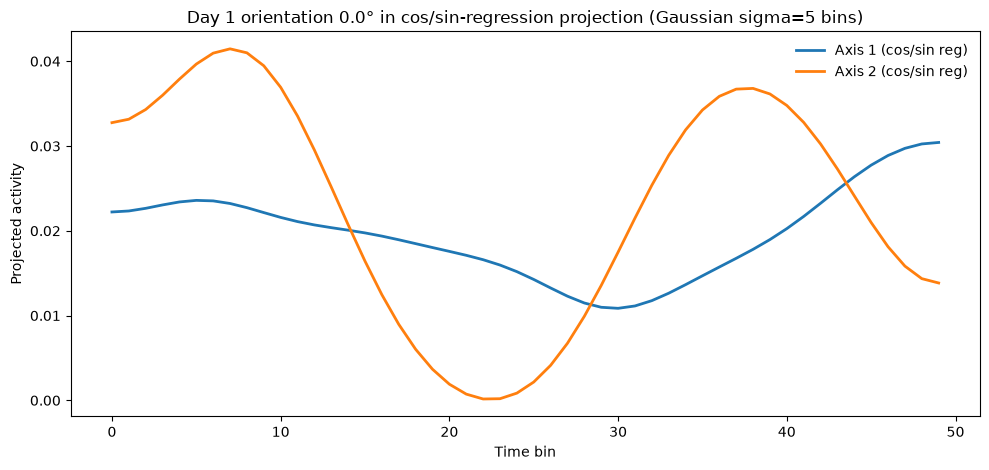

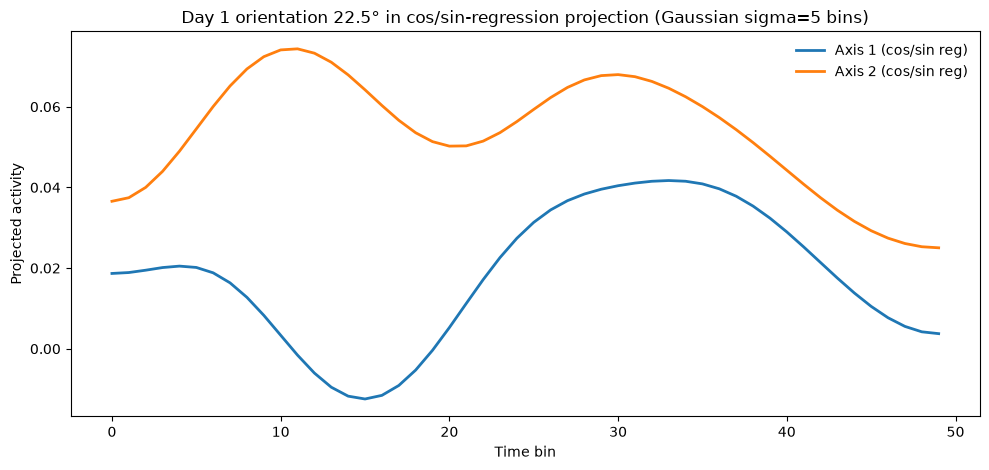

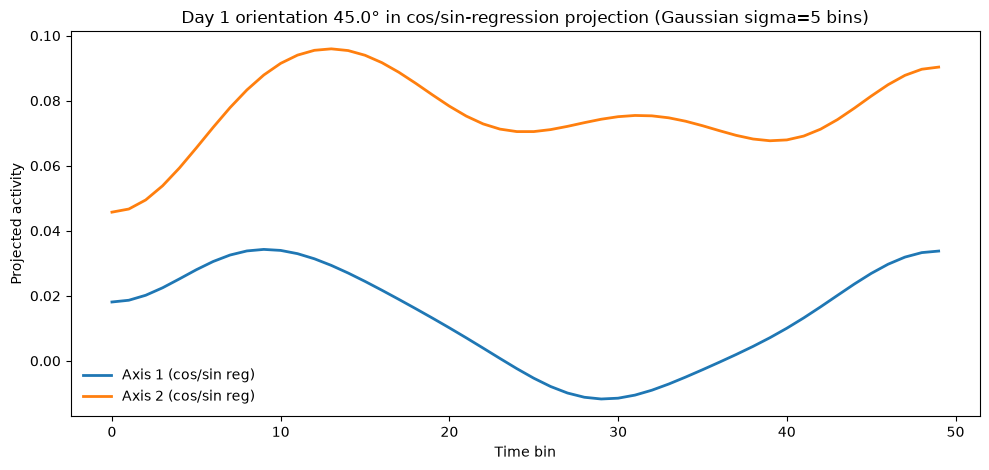

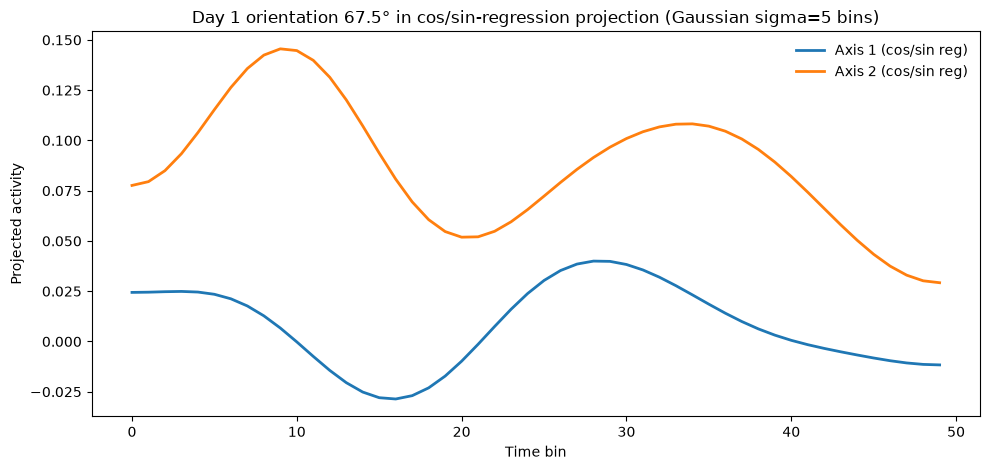

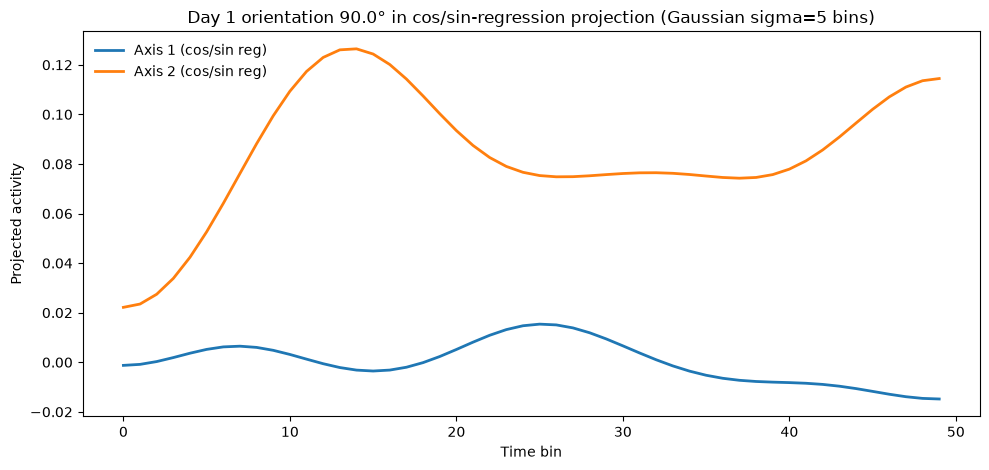

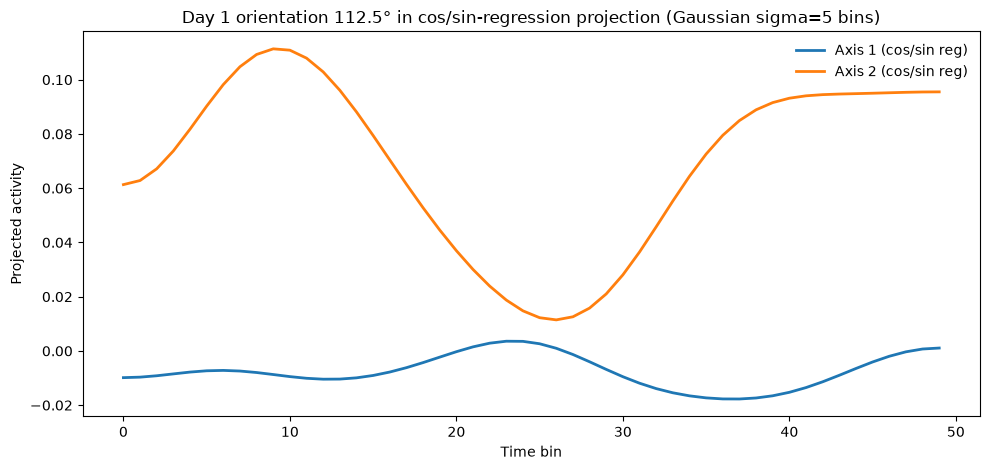

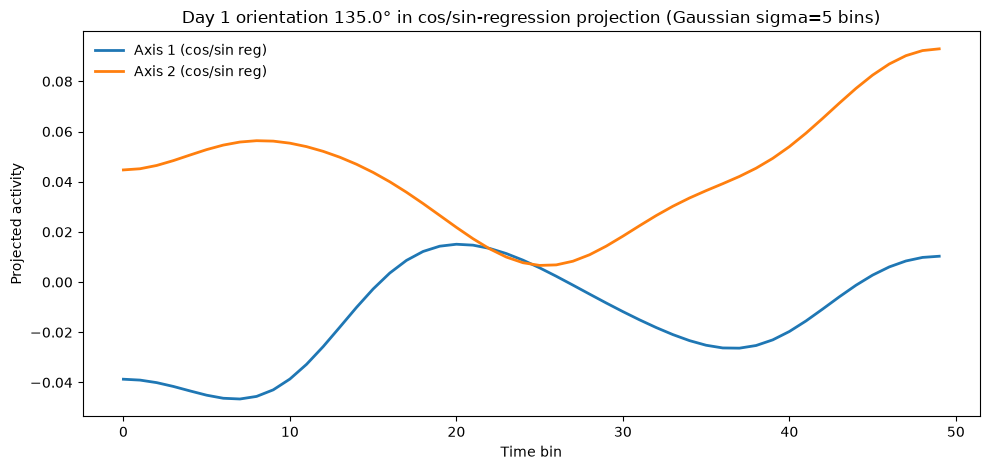

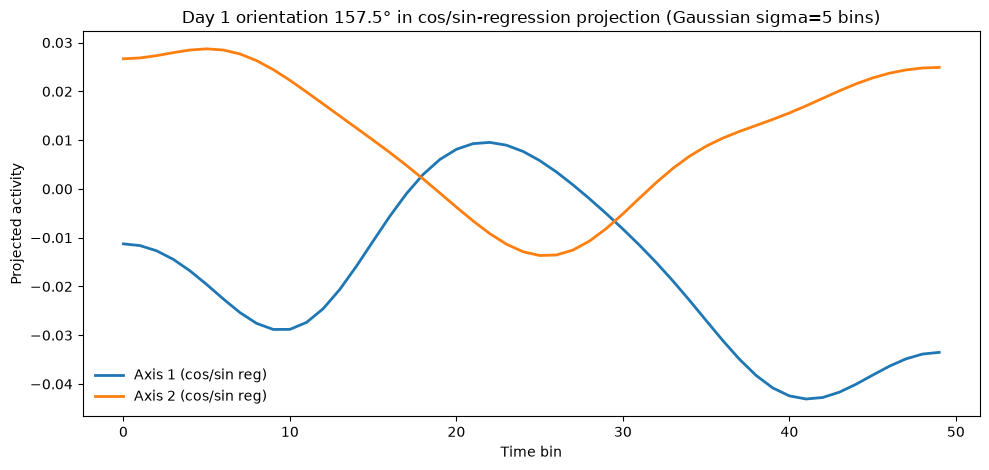

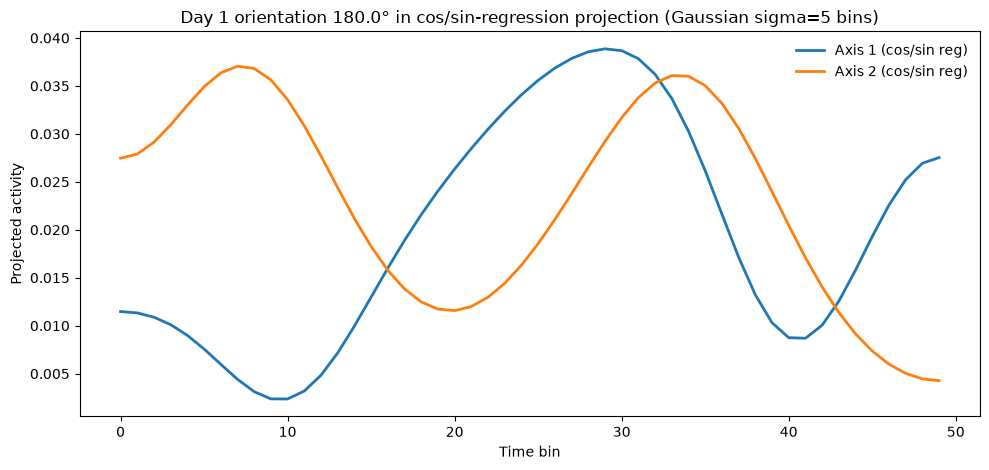

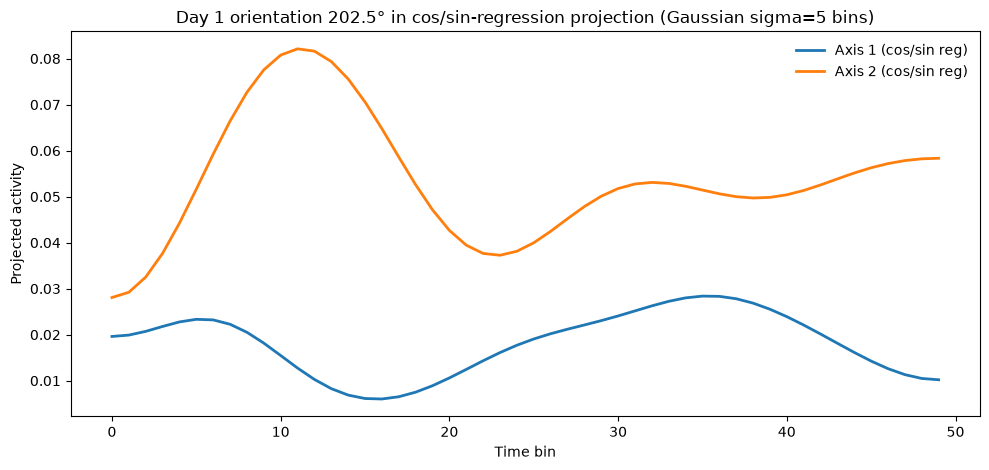

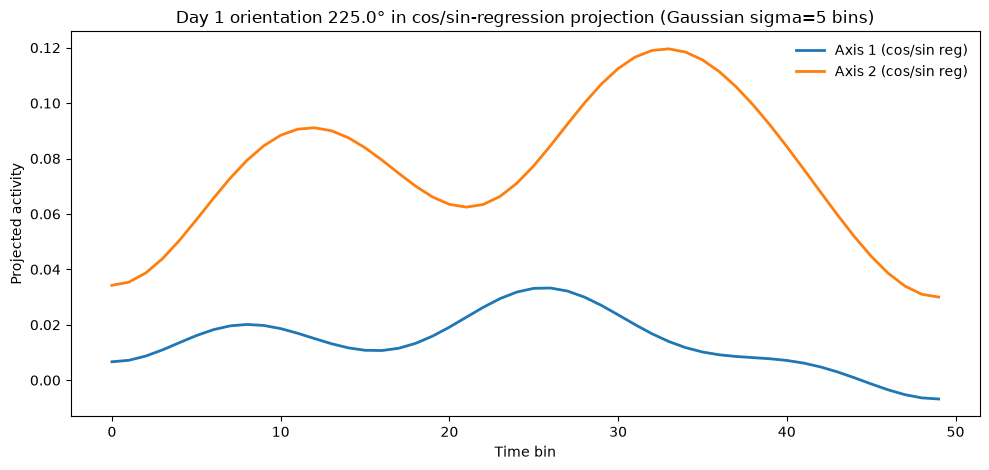

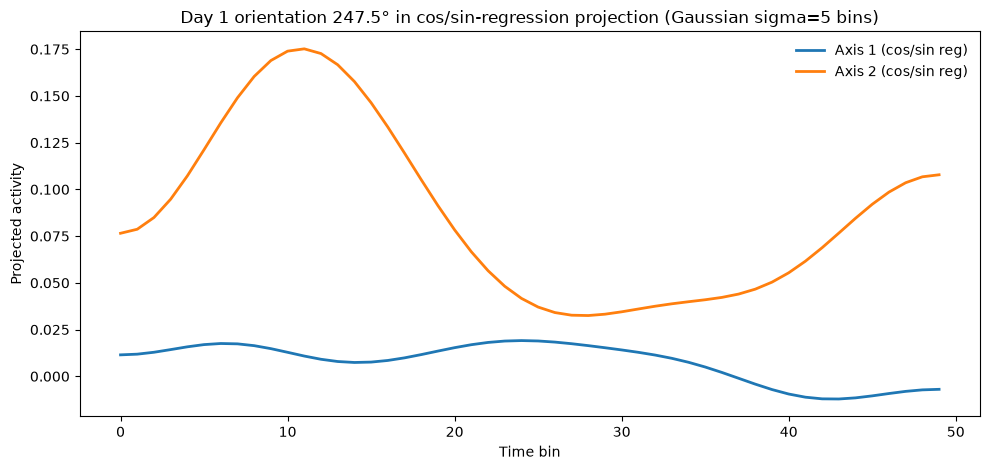

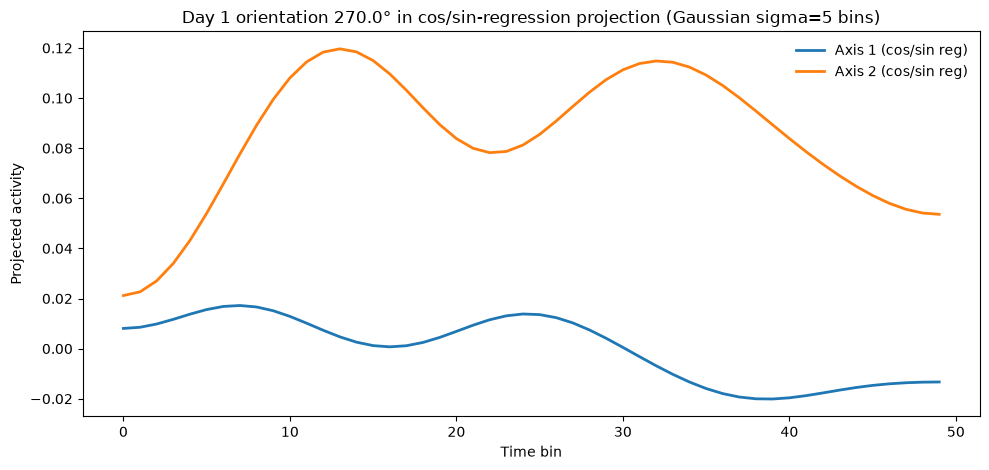

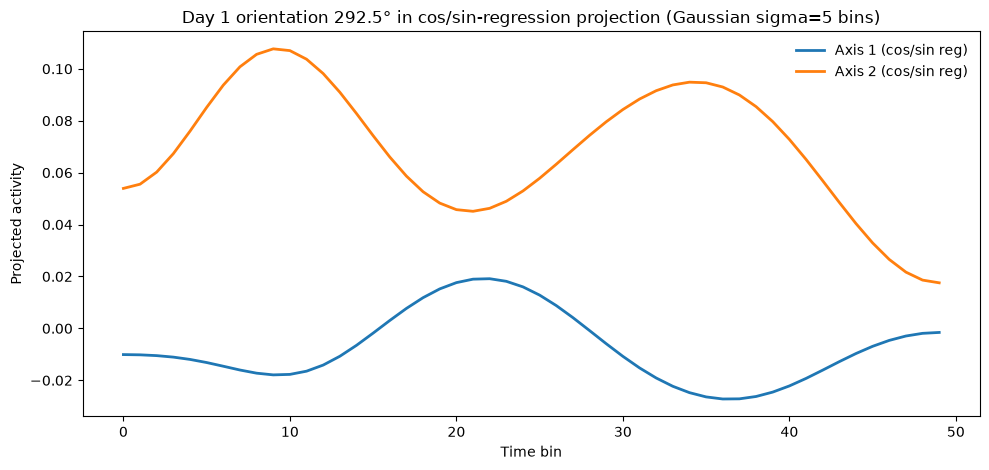

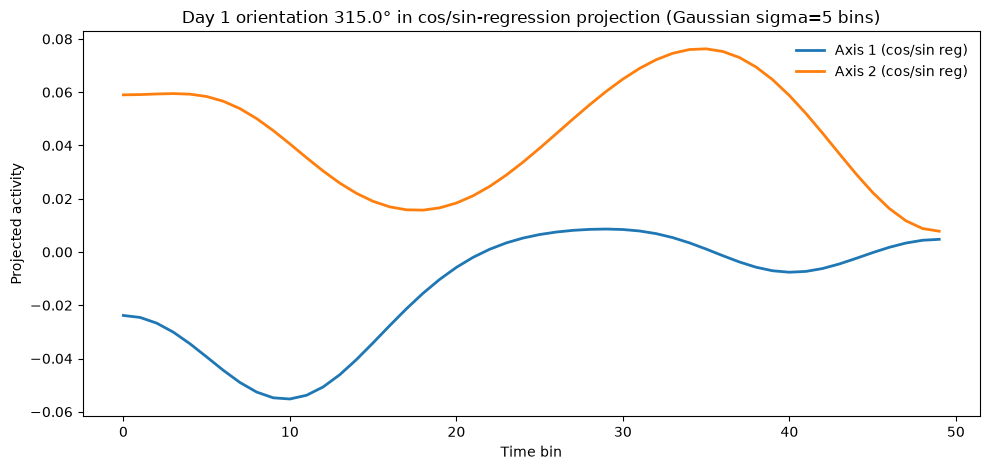

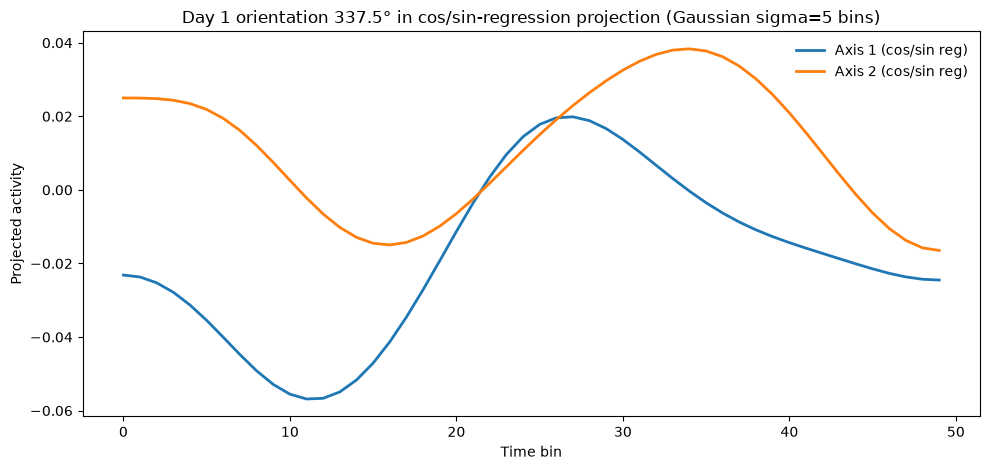

In [240]:
import numpy as np
import matplotlib.pyplot as plt


def gaussian_smooth_time(neuron_time, sigma_bins=5.0):
    # Smooth along time axis for an array shaped (neurons x time).
    radius = int(np.ceil(4 * sigma_bins))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel /= kernel.sum()

    padded = np.pad(neuron_time, ((0, 0), (radius, radius)), mode='reflect')
    smoothed = np.array([np.convolve(row, kernel, mode='valid') for row in padded])
    return smoothed


# Learn orientation projection from time-collapsed, trial-averaged activity.
responses_day1 = z_day1['responses']
orientations_day1 = z_day1['orientation']
valid_orientations = np.unique(orientations_day1[~np.isnan(orientations_day1)])

gaussian_sigma_bins = 5.0

if valid_orientations.size < 2:
    raise ValueError('Need at least two orientations to learn a 2D regression projection.')

trialavg_timecollapsed = []
used_orientations = []
for ori in valid_orientations:
    omask = np.isclose(orientations_day1, ori)
    if np.any(omask):
        # Trial-average first (neurons x time), smooth in time, then collapse time -> neurons.
        mean_nt = responses_day1[omask].mean(axis=0)
        mean_nt_smooth = gaussian_smooth_time(mean_nt, sigma_bins=gaussian_sigma_bins)
        mean_n = mean_nt_smooth.sum(axis=-1)
        trialavg_timecollapsed.append(mean_n)
        used_orientations.append(ori)

X = np.vstack(trialavg_timecollapsed)  # orientations x neurons
used_orientations = np.asarray(used_orientations)

# Theta uses orientation mod 180, as requested.
theta_deg = np.mod(used_orientations, 180.0)
theta_rad = np.deg2rad(theta_deg)
Y = np.column_stack([np.cos(theta_rad), np.sin(theta_rad)])

# Regression to cos(theta), sin(theta), then QR for 2D orthonormal basis in neuron space.
regression_matrix, *_ = np.linalg.lstsq(X, Y, rcond=None)  # neurons x 2
projection_basis, _ = np.linalg.qr(regression_matrix)
projection_basis = projection_basis[:, :2]  # neurons x 2

# Pick one orientation and project its smoothed trial-averaged activity over time.
for target_orientation in used_orientations:
    tmask = np.isclose(orientations_day1, target_orientation)
    if not np.any(tmask):
        raise ValueError(f'No trials found for orientation {target_orientation}.')

    target_mean_nt = responses_day1[tmask].mean(axis=0)  # neurons x time
    target_mean_nt_smooth = gaussian_smooth_time(target_mean_nt, sigma_bins=gaussian_sigma_bins)
    time_projection = target_mean_nt_smooth.T @ projection_basis  # time x 2

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(time_projection[:, 0], label='Axis 1 (cos/sin reg)', linewidth=2.0)
    ax.plot(time_projection[:, 1], label='Axis 2 (cos/sin reg)', linewidth=2.0)
    ax.set_xlabel('Time bin')
    ax.set_ylabel('Projected activity')
    ax.set_title(f'Day 1 orientation {target_orientation:.1f}° in cos/sin-regression projection (Gaussian sigma=5 bins)')
    ax.legend(frameon=False)
    fig.tight_layout()

    print('Gaussian smoothing sigma (bins):', gaussian_sigma_bins)
    print('Regression fit matrix shape (neurons x 2):', regression_matrix.shape)
    print('Projection basis shape (neurons x 2):', projection_basis.shape)
    print('Target mean activity shape (neurons x time):', target_mean_nt.shape)
    print('Smoothed target mean shape (neurons x time):', target_mean_nt_smooth.shape)
    print('Projected time-course shape (time x 2):', time_projection.shape)